# Score-Only Goodness of Fit: Sequential Kernelized Stein Discrepancy

## Demonstrates anytime-valid goodness-of-fit testing when only the score is available:
- Betting against a target you can differentiate but cannot normalise
- A correct model: capital stays near 1, no rejection however long you watch
- Same mean, same variance, wrong tails: standardised t(3) against a Gaussian target
- Compactly supported Wendland kernels: no moment condition, local Lipschitz only
- Betting strategy comparison (ALL_IN, CONSERVATIVE, EMPIRICALLY_ADAPTIVE)
- Type-I error validity under H0
- Real-world: checking a fitted 2-D residual model in production
- Real-world: validating a molecular-simulation sampler at the wrong temperature
- The known blind spot: well-separated mixture weights

The normalising constant is the obstacle in most modern generative and Bayesian
models: energy-based models, Gibbs/Boltzmann distributions, unnormalised posteriors,
score-based diffusions. All of them give you grad log p(x) and none of them give you
p(x). Stein's identity turns the score into a test: under the target, the Stein kernel
h_p has mean zero, so betting on it is a fair game and any accumulation of capital is
evidence that the sample does not come from p.

Skeptic emits E_t = 1 + sum_i h_p(X_i, x) / sum_i M_p(X_i) >= 0 each round
(Martinez-Taboada & Ramdas 2025, Eq. (5)), so the library's existing combiners bet
1 + lambda g_t on it and `BettingProtocol` supplies Ville's inequality.

**How the simulations are set up.** Every stream below comes from a mechanism rather than
a hand-written probability law: a sampler that is genuinely biased by its discretisation,
residuals built from a common factor plus idiosyncratic noise, a thermostat at the wrong
temperature. Single runs are shown for the shape of the capital curve, and every
detection claim is backed by replications so that one lucky seed cannot carry the point.

References:
    Martinez-Taboada & Ramdas (2025). Sequential Kernelized Stein Discrepancy.
    AISTATS. arXiv:2409.17505.
    - Eq. (1): the Stein kernel h_p;  Eq. (5): the betting payoff and its lower bound
    - Theorem 1: anytime validity;  Theorem 2: power
    - Section 5.1: IMQ and compactly supported kernels
    Liu, Lee & Jordan (2016); Chwialkowski, Strathmann & Gretton (2016):
    kernel Stein discrepancy (Chwialkowski et al., Lemma 5.1 for the Stein identity).
    Gorham & Mackey (2017). Measuring sample quality with kernels - why IMQ.
    Wendland (1995). Piecewise polynomial, positive definite and compactly supported
    radial functions of minimal degree.
    Wenliang & Kanagawa (2020). Blindness of score-based methods to isolated components.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from expectation.modules.protocol import BettingProtocol
from expectation.modules.hypothesistesting import EProcessConfig, BettingStrategy
from expectation.stein.kernels import IMQSteinKernel, WendlandSteinKernel
from expectation.stein.skeptic import BoltzmannTarget, GaussianTarget, SteinSkeptic

ALPHA = 0.05

# EMPIRICALLY_ADAPTIVE with gamma = 1 is the GRAPA-type rule; the Stein payoff is
# already in [-1, inf), so the combiner only has to choose the stake.
ADAPTIVE = EProcessConfig(
    significance_level=ALPHA,
    betting_strategy=BettingStrategy.EMPIRICALLY_ADAPTIVE,
    gamma=1.0,
)

# 1. Betting Against a Target You Can Only Score

Test H0: X_t ~ p (given the past) vs H1: it does not.

The target enters only through grad log p. `GaussianTarget` supplies that score and
the Lipschitz constant of the score that the kernel's lower bound needs;
`IMQSteinKernel` is the inverse multi-quadric base kernel recommended by Gorham &
Mackey (2017) because it does not lose sensitivity in the tails.

Each round Skeptic computes the payoff of Eq. (5) against the reference points seen so
far, `BettingProtocol` checks it is a legitimate e-value before touching any state, and
the combiner sizes the bet. `max_reference_size` freezes the reference set after a
fixed number of points, which is a predictable rule and bounds the per-round cost.

Two streams, same target: one that really is N(0, 1), one shifted by 0.4.

In [2]:
target = GaussianTarget(mean=[0.0])          # score -(x - 0), Lipschitz constant 1
kernel = IMQSteinKernel(dim=1)

n_draws = 2000
streams = {
    "correct: N(0, 1)":  np.random.default_rng(0).standard_normal(n_draws),
    "shifted: N(0.4, 1)": np.random.default_rng(1).standard_normal(n_draws) + 0.4,
}

runs = {}
for name, draws in streams.items():
    protocol = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=200), ADAPTIVE)
    stop = None
    for i, x in enumerate(draws):
        result = protocol.update(np.atleast_1d(x))
        if result.reject_null:
            stop = i + 1
            break
    runs[name] = protocol
    if stop:
        print(f"{name:20s}: rejected after {stop:4d} draws "
              f"(capital {protocol.get_summary()['max_e_process']:.1f})")
    else:
        print(f"{name:20s}: no rejection in {protocol.step:4d} draws "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

# A single run is a single draw. Replicate before believing either result.
print()
for name, shift in (("correct: N(0, 1)", 0.0), ("shifted: N(0.4, 1)", 0.4)):
    stops = []
    for rep in range(10):
        rng_rep = np.random.default_rng(200 + rep)
        proto = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=200), ADAPTIVE)
        stop = None
        for i, x in enumerate(rng_rep.standard_normal(n_draws) + shift):
            if proto.update(np.atleast_1d(x)).reject_null:
                stop = i + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"10 replications, {name:20s}: rejected {len(detected)}/10, median {median:.0f} draws")

correct: N(0, 1)    : no rejection in 2000 draws (max capital 1.330)
shifted: N(0.4, 1)  : rejected after   55 draws (capital 21.7)



10 replications, correct: N(0, 1)    : rejected 0/10, median nan draws


10 replications, shifted: N(0.4, 1)  : rejected 10/10, median 100 draws


# 2. Same Mean, Same Variance, Wrong Tails

The interesting failures of a sampler are rarely a shifted mean, which every moment
check catches. They are shape failures: the right centre and the right spread but the
wrong tails, which is what a heavy-tailed proposal, a truncated chain or an
under-trained flow produces.

We standardise Student-t(3) to unit population variance, so the first two moments
match the Gaussian target and the only signal left is the shape of the score. The
*sample* variance still wanders, because t(3) has infinite kurtosis - which is itself
a reminder that moment-based checks are a poor instrument for this failure mode.

sample mean     : +0.0161  (population 0)
sample variance : 0.8642  (population 1, noisily estimated)
sample kurtosis : 12.51  (Gaussian 3, t(3) infinite)

standardised t(3) against N(0, 1): rejected after 52 draws


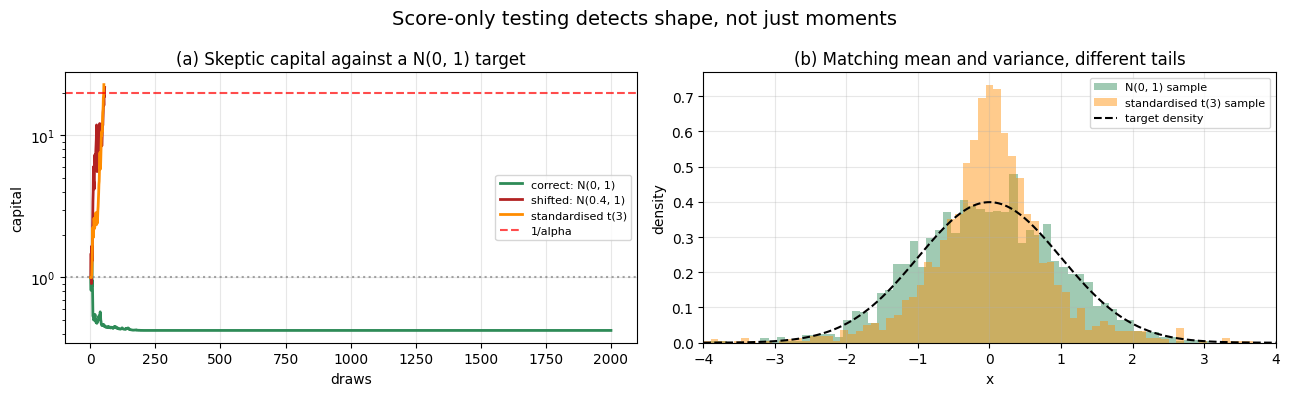

In [3]:
rng = np.random.default_rng(2)
heavy_tailed = rng.standard_t(3, 2000) / np.sqrt(3.0)   # unit variance, t(3) shape

print(f"sample mean     : {heavy_tailed.mean():+.4f}  (population 0)")
print(f"sample variance : {heavy_tailed.var():.4f}  (population 1, noisily estimated)")
print(f"sample kurtosis : {((heavy_tailed - heavy_tailed.mean())**4).mean() / heavy_tailed.var()**2:.2f}"
      f"  (Gaussian 3, t(3) infinite)")
print()

protocol_t = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=200), ADAPTIVE)
stop_t = None
for i, x in enumerate(heavy_tailed):
    if protocol_t.update(np.atleast_1d(x)).reject_null:
        stop_t = i + 1
        break
print(f"standardised t(3) against N(0, 1): rejected after {stop_t} draws")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for name, colour in zip(streams, ('seagreen', 'firebrick')):
    df = runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
df_t = protocol_t.get_history_df()
ax.plot(df_t['step'], df_t['e_process_value'], lw=2, color='darkorange',
        label='standardised t(3)')
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('draws'); ax.set_ylabel('capital')
ax.set_title('(a) Skeptic capital against a N(0, 1) target')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
grid = np.linspace(-4, 4, 400)
ax.hist(streams['correct: N(0, 1)'], bins=60, density=True, alpha=0.45,
        color='seagreen', label='N(0, 1) sample')
ax.hist(heavy_tailed, bins=120, density=True, alpha=0.45, color='darkorange',
        label='standardised t(3) sample')
ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.5, label='target density')
ax.set_xlim(-4, 4); ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_title('(b) Matching mean and variance, different tails')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Score-only testing detects shape, not just moments', fontsize=14)
plt.tight_layout()
plt.show()

# 3. Compactly Supported Kernels: No Moment Condition Required

The IMQ kernel needs a **global** Lipschitz constant of the score. Many interesting
targets do not have one: any potential growing faster than quadratically has a score
whose derivative is unbounded, which rules out IMQ-style bounds.

`WendlandSteinKernel` has compact support (Wendland 1995), so the Stein identity holds
for every C^1 positive density with no moment condition at all, and only a **local**
Lipschitz constant on the support ball is needed. `SteinSkeptic` refuses an IMQ kernel
without a global constant rather than silently producing an invalid bound.

The canonical hard target is the quartic double well, U(x) = (x^2 - 1)^2, whose
Boltzmann density has two modes. We give `BoltzmannTarget` the gradient of the
potential and a local Lipschitz function - that is the target *specification* the
construction requires, not a statistical choice - then test two samplers:

- an exact sampler for the double well, which should never be rejected, and
- a tamed unadjusted Langevin sampler, which is a standard, *biased* discretisation.
  Its bias is exactly the kind of defect the test exists to find.

double well needs a global Lipschitz score? no global constant available
IMQ requires one: True
Wendland requires one: False

exact sampler       : no rejection in 2000 draws (max capital 1.041)


tamed ULA (biased)  : rejected after  196 draws



6 replications, exact sampler       : rejected 0/6, median nan draws


6 replications, tamed ULA (biased)  : rejected 6/6, median 260 draws


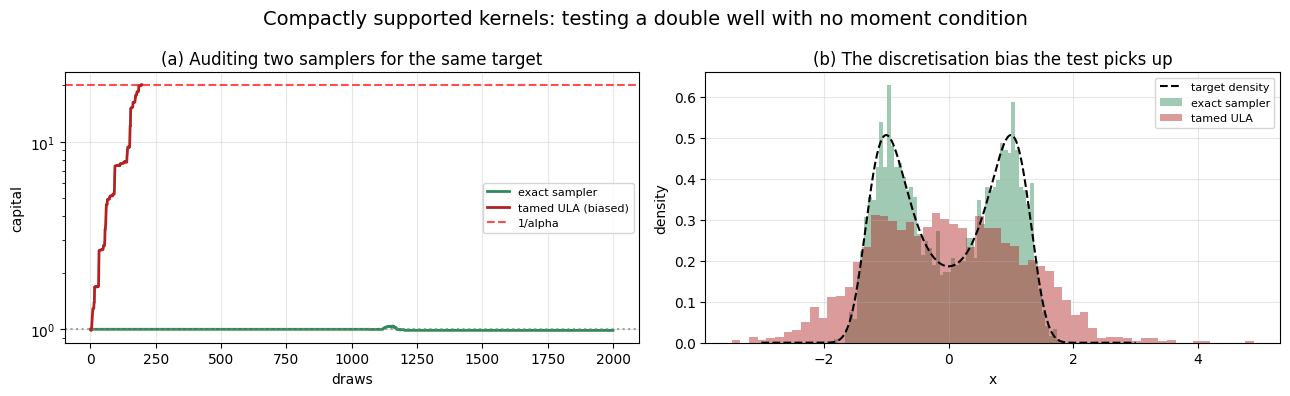

In [4]:
# Target specification: p(x) ∝ exp(-U(x)) with U(x) = (x^2 - 1)^2.
grad_potential = lambda x: 4.0 * x**3 - 4.0 * x                      # grad U
local_lipschitz = lambda y, r: max(12.0 * (np.abs(y).max() + r)**2 - 4.0, 4.0)   # sup |U''| on B(y, r)

double_well = BoltzmannTarget(
    grad_potential, beta=1.0, dim=1, local_lipschitz_grad_potential=local_lipschitz
)
wendland = WendlandSteinKernel(dim=1, radius=1.5)

print(f"double well needs a global Lipschitz score? "
      f"{double_well.lipschitz is None and 'no global constant available' or double_well.lipschitz}")
print(f"IMQ requires one: {IMQSteinKernel(dim=1).requires_global_lipschitz}")
print(f"Wendland requires one: {wendland.requires_global_lipschitz}")
print()

rng = np.random.default_rng(1)

# Exact draws from the double well by inverse-CDF on a fine grid (data simulation only).
grid = np.linspace(-3, 3, 20001)
density = np.exp(-((grid**2 - 1)**2))
cdf = np.cumsum(density)
cdf /= cdf[-1]
exact_draws = np.interp(rng.random(2000), cdf, grid)

# A biased sampler: tamed unadjusted Langevin, step 0.3, no Metropolis correction.
step, x = 0.3, 0.0
tamed_draws = np.empty(2000)
for i in range(2000):
    g = grad_potential(np.array([x]))[0]
    x = x - step * g / (1 + step * abs(g)) + np.sqrt(2 * step) * rng.standard_normal()
    tamed_draws[i] = x

samplers = {"exact sampler": exact_draws, "tamed ULA (biased)": tamed_draws}
well_runs = {}

for name, draws in samplers.items():
    protocol = BettingProtocol(
        SteinSkeptic(double_well, wendland, max_reference_size=200), ADAPTIVE
    )
    stop = None
    for i, x_t in enumerate(draws):
        if protocol.update(np.atleast_1d(x_t)).reject_null:
            stop = i + 1
            break
    well_runs[name] = protocol
    if stop:
        print(f"{name:20s}: rejected after {stop:4d} draws")
    else:
        print(f"{name:20s}: no rejection in {protocol.step:4d} draws "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

print()
for name in samplers:
    stops = []
    for rep in range(6):
        rng_rep = np.random.default_rng(300 + rep)
        if name == "exact sampler":
            draws_rep = np.interp(rng_rep.random(1500), cdf, grid)
        else:
            draws_rep = np.empty(1500)
            x_rep = 0.0
            for i in range(1500):
                g_rep = grad_potential(np.array([x_rep]))[0]
                x_rep = (x_rep - step * g_rep / (1 + step * abs(g_rep))
                         + np.sqrt(2 * step) * rng_rep.standard_normal())
                draws_rep[i] = x_rep
        proto = BettingProtocol(
            SteinSkeptic(double_well, wendland, max_reference_size=200), ADAPTIVE
        )
        stop = None
        for i, x_t in enumerate(draws_rep):
            if proto.update(np.atleast_1d(x_t)).reject_null:
                stop = i + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"6 replications, {name:20s}: rejected {len(detected)}/6, median {median:.0f} draws")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for name, colour in zip(samplers, ('seagreen', 'firebrick')):
    df = well_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('draws'); ax.set_ylabel('capital')
ax.set_title('(a) Auditing two samplers for the same target')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(grid, density / (density.sum() * (grid[1] - grid[0])), 'k--', lw=1.5,
        label='target density')
ax.hist(exact_draws, bins=60, density=True, alpha=0.45, color='seagreen', label='exact sampler')
ax.hist(tamed_draws, bins=60, density=True, alpha=0.45, color='firebrick', label='tamed ULA')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_title('(b) The discretisation bias the test picks up')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Compactly supported kernels: testing a double well with no moment condition',
             fontsize=14)
plt.tight_layout()
plt.show()

# 4. Betting Strategy Comparison

The Stein payoff is fixed by the target and the kernel; what remains is how much of
the capital to stake each round. That is the library's existing combiner machinery,
unchanged - `SteinSkeptic` plugs into `EProcessUpdater` like any other strategy.

- **ALL_IN** stakes everything: fastest when the alternative is clear, most fragile
  when it is not.
- **CONSERVATIVE** stakes a fixed small fraction: slowest, steadiest.
- **EMPIRICALLY_ADAPTIVE** (gamma = 1) is the GRAPA-type rule: it estimates the stake
  from the payoffs seen so far, so it approaches all-in when the evidence is
  consistent and pulls back when it is not.

ALL_IN                : rejected after 127 draws (capital 21.3)
CONSERVATIVE          : rejected after 180 draws (capital 21.0)
EMPIRICALLY_ADAPTIVE  : rejected after 127 draws (capital 20.6)


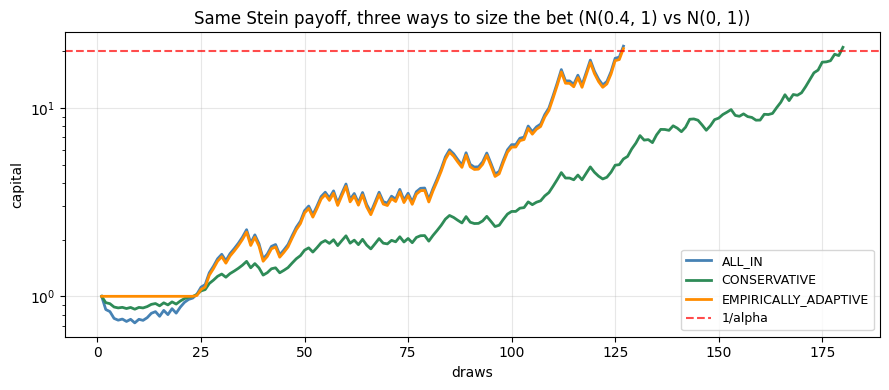

In [5]:
draws = np.random.default_rng(3).standard_normal(1500) + 0.4

strategies = {
    "ALL_IN": BettingStrategy.ALL_IN,
    "CONSERVATIVE": BettingStrategy.CONSERVATIVE,
    "EMPIRICALLY_ADAPTIVE": BettingStrategy.EMPIRICALLY_ADAPTIVE,
}

strategy_runs = {}
for name, strategy in strategies.items():
    config = EProcessConfig(significance_level=ALPHA, betting_strategy=strategy, gamma=1.0)
    protocol = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=200), config)
    stop = None
    for i, x in enumerate(draws):
        if protocol.update(np.atleast_1d(x)).reject_null:
            stop = i + 1
            break
    strategy_runs[name] = protocol
    print(f"{name:22s}: rejected after {stop} draws "
          f"(capital {protocol.get_summary()['max_e_process']:.1f})")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in zip(strategies, ('steelblue', 'seagreen', 'darkorange')):
    df = strategy_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.set_yscale('log'); ax.set_xlabel('draws'); ax.set_ylabel('capital')
ax.set_title('Same Stein payoff, three ways to size the bet (N(0.4, 1) vs N(0, 1))')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Type-I Error Validity Under H0

When the sample really does come from the target, the capital process is a
nonnegative supermartingale starting at 1, so Ville's inequality bounds the
probability that it *ever* reaches 1/alpha - over the whole run, under optional
stopping, no matter how often the sampler is inspected.

We run 200 independent audits of a correct sampler and count how many ever fire.

In [6]:
n_simulations, n_draws_sim = 200, 300
rejections = 0
final_capital = []

for sim in range(n_simulations):
    draws_sim = np.random.default_rng(4000 + sim).standard_normal(n_draws_sim)
    protocol = BettingProtocol(SteinSkeptic(target, kernel, max_reference_size=150), ADAPTIVE)
    rejected = False
    for x in draws_sim:
        if protocol.update(np.atleast_1d(x)).reject_null:
            rejected = True
            break
    rejections += rejected
    final_capital.append(protocol.get_summary()['max_e_process'])

rate = rejections / n_simulations
se = np.sqrt(ALPHA * (1 - ALPHA) / n_simulations)

print(f"Type-I simulation (the sampler is correct)")
print(f"  Audits:             {n_simulations}")
print(f"  Draws per audit:    {n_draws_sim} (checked after every draw)")
print(f"  Rejections:         {rejections}")
print(f"  Rejection rate:     {rate:.3f}")
print(f"  Nominal alpha:      {ALPHA} (+/- {1.96 * se:.3f} Monte Carlo)")
print(f"  Valid:              {rate <= ALPHA + 3 * se}")
print(f"  Median max capital: {np.median(final_capital):.3f} (rejection needs {1 / ALPHA:.0f})")

Type-I simulation (the sampler is correct)
  Audits:             200
  Draws per audit:    300 (checked after every draw)
  Rejections:         1
  Rejection rate:     0.005
  Nominal alpha:      0.05 (+/- 0.030 Monte Carlo)
  Valid:              True
  Median max capital: 1.000 (rejection needs 20)


# 6. Real World: Checking a Fitted Residual Model In Production

**Scenario:** A risk model produces two-dimensional standardised residuals - say
predicted-vs-actual error on two correlated exposures, or the innovations of a
two-factor state-space model. The model was fitted offline and assumes the residuals
are jointly Gaussian with a correlation of 0.6. Downstream, that correlation drives
the capital charge: if it is wrong, the aggregate risk number is wrong.

- **Target:** N(0, [[1, 0.6], [0.6, 1]]). Scoring it is trivial; the point is that the
  same machinery applies to any model whose score is available, including the ones
  with no tractable normaliser.
- **How the data are made:** each residual pair is built from a common factor plus
  idiosyncratic noise, which is how exposures actually co-move. The observable
  correlation is a consequence of the factor loading - no covariance matrix is written
  down by hand.
- **Failure mode 1:** the common factor explains far less than the model assumes - a
  hedge that never worked as well as the backtest suggested. Marginals are unchanged, so
  every univariate monitor stays green.
- **Failure mode 2:** volatility is understated by half. The correlation is right, the
  shape is right, only the scale is wrong.

**Why sequential testing matters here:**
- Model validation is continuous in a production risk system, not a quarterly report.
  An e-process is valid at every observation, so a validator may look whenever they
  like without spending alpha.
- Both failure modes are invisible to the checks people usually run - failure 1 passes
  every marginal test, failure 2 passes every correlation test.
- The capital process is directly interpretable as evidence, which is what a model risk
  committee has to sign off on.

**Realistic parameters:** a few hundred observations for either failure - one to two
quarters of daily data - with the replications below showing how reliably. Note what the
test does *not* do: a correctly specified model is never rejected, however long the
validator watches.

model holds             : no rejection in 1500 observations (max capital 3.994)


common factor weaker    : model rejected after  223 observations


volatility understated  : model rejected after  298 observations



6 replications, model holds             : rejected 0/6, median nan observations


6 replications, common factor weaker    : rejected 6/6, median 424 observations


6 replications, volatility understated  : rejected 6/6, median 400 observations


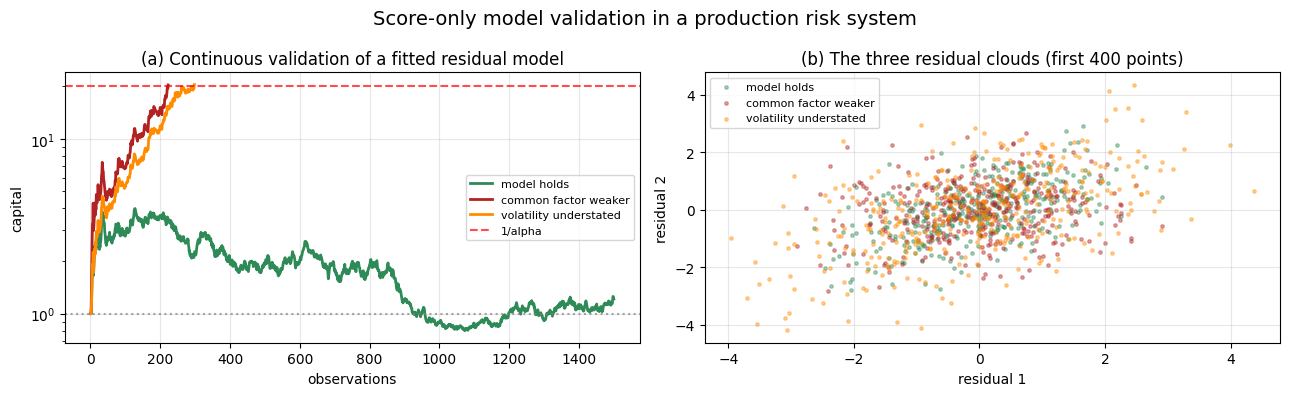

In [7]:
model_correlation = 0.6
residual_target = GaussianTarget(mean=[0.0, 0.0],
                                 cov=[[1.0, model_correlation], [model_correlation, 1.0]])
kernel_2d = IMQSteinKernel(dim=2)


def two_factor_residuals(n, common_variance, scale, rng):
    """Residuals from a common factor plus idiosyncratic noise, then a volatility scale.

    The observable correlation is `common_variance`; the model assumes 0.6. Nothing is
    written down as a covariance matrix - it falls out of how the exposures are built.
    """
    loading = np.sqrt(common_variance)
    factor = rng.standard_normal(n)
    idiosyncratic = rng.standard_normal((n, 2))
    residuals = (loading * factor)[:, None] + np.sqrt(1 - loading**2) * idiosyncratic
    return scale * residuals


worlds = {
    "model holds":          dict(common_variance=0.6, scale=1.0),
    "common factor weaker": dict(common_variance=0.2, scale=1.0),
    "volatility understated": dict(common_variance=0.6, scale=1.5),
}

n_observations, n_replications = 1500, 6
residual_runs = {}

for name, params in worlds.items():
    protocol = BettingProtocol(
        SteinSkeptic(residual_target, kernel_2d, max_reference_size=150), ADAPTIVE
    )
    draws = two_factor_residuals(n_observations, rng=np.random.default_rng(5), **params)
    stop = None
    for i, x in enumerate(draws):
        if protocol.update(x).reject_null:
            stop = i + 1
            break
    residual_runs[name] = (protocol, draws)
    if stop:
        print(f"{name:24s}: model rejected after {stop:4d} observations")
    else:
        print(f"{name:24s}: no rejection in {protocol.step:4d} observations "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

print()
for name, params in worlds.items():
    stops = []
    for rep in range(n_replications):
        rng_rep = np.random.default_rng(120 + rep)
        proto = BettingProtocol(
            SteinSkeptic(residual_target, kernel_2d, max_reference_size=150), ADAPTIVE
        )
        stop = None
        for i, x in enumerate(two_factor_residuals(n_observations, rng=rng_rep, **params)):
            if proto.update(x).reject_null:
                stop = i + 1
                break
        stops.append(stop)
    detected = [s for s in stops if s is not None]
    median = np.median(detected) if detected else float('nan')
    print(f"{n_replications} replications, {name:24s}: rejected {len(detected)}/"
          f"{n_replications}, median {median:.0f} observations")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for name, colour in zip(worlds, ('seagreen', 'firebrick', 'darkorange')):
    df = residual_runs[name][0].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('observations'); ax.set_ylabel('capital')
ax.set_title('(a) Continuous validation of a fitted residual model')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for name, colour in zip(worlds, ('seagreen', 'firebrick', 'darkorange')):
    sample = residual_runs[name][1][:400]
    ax.scatter(sample[:, 0], sample[:, 1], s=6, alpha=0.4, color=colour, label=name)
ax.set_xlabel('residual 1'); ax.set_ylabel('residual 2')
ax.set_title('(b) The three residual clouds (first 400 points)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Score-only model validation in a production risk system', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Real World: A Molecular Simulation Running At the Wrong Temperature

**Scenario:** A molecular dynamics or Monte Carlo code samples a Boltzmann
distribution p ∝ exp(-beta U). A thermostat bug, an inconsistent unit conversion or a
wrong mass matrix leaves the simulation equilibrating at the wrong effective
temperature. The configurations look completely plausible - the right modes, the right
shapes - and the error only shows up in ensemble averages, i.e. in the published
numbers.

- **Target:** the Boltzmann law of the intended potential at the intended beta. The
  partition function is unavailable, which is why score-based testing is the natural
  tool rather than a convenience.
- **Failure:** the sampler equilibrates at temperature 1.25 or 1.5 instead of 1.0.
- **What is being validated:** the *sampler*, not the physics. A wrong-temperature run
  is a valid sample from the wrong distribution.

**Why sequential testing matters here:**
- Simulation time is the budget. Detecting a thermostat bug after 700 configurations
  instead of at the end of a week-long production run is the whole value proposition.
- Runs are monitored while they are running, with no fixed sample size, so the test has
  to be valid under continuous inspection.
- A 25% temperature error is a subtle, realistic defect - not a broken simulation, just
  a wrong one, and exactly the kind that survives eyeballing the trajectories.

**Realistic parameters:** a harmonic trap with a global Lipschitz score, so the IMQ
kernel applies. A 50% temperature error is caught in a few hundred configurations; a
25% error takes a few thousand.

correct (T = 1.0)   : no rejection in  3000 configurations (max capital 1.323)


thermostat 25% hot  : sampler rejected after  1778 configurations


thermostat 50% hot  : sampler rejected after   735 configurations


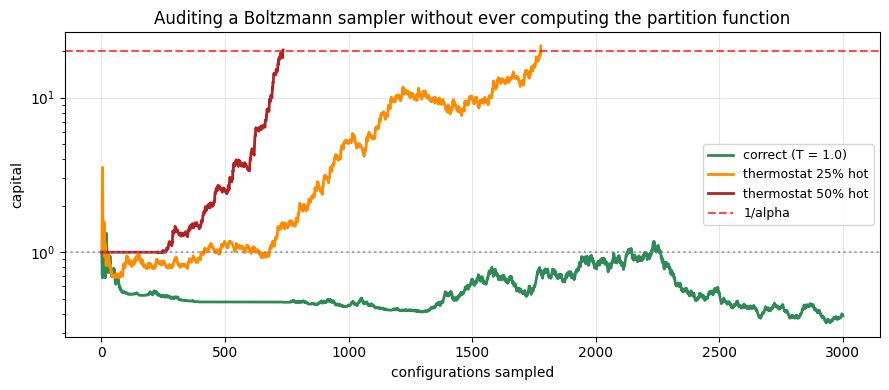

In [8]:
spring_constant = 1.0
trap = BoltzmannTarget(
    lambda x: spring_constant * x,       # grad U for U(x) = k x^2 / 2
    beta=1.0,
    dim=1,
    lipschitz_grad_potential=spring_constant,
)

rng = np.random.default_rng(6)
temperatures = {"correct (T = 1.0)": 1.0, "thermostat 25% hot": 1.25, "thermostat 50% hot": 1.5}

trap_runs = {}
for name, temperature in temperatures.items():
    configurations = np.sqrt(temperature / spring_constant) * rng.standard_normal(3000)
    protocol = BettingProtocol(SteinSkeptic(trap, kernel, max_reference_size=200), ADAPTIVE)
    stop = None
    for i, x in enumerate(configurations):
        if protocol.update(np.atleast_1d(x)).reject_null:
            stop = i + 1
            break
    trap_runs[name] = protocol
    if stop:
        print(f"{name:20s}: sampler rejected after {stop:5d} configurations")
    else:
        print(f"{name:20s}: no rejection in {protocol.step:5d} configurations "
              f"(max capital {protocol.get_summary()['max_e_process']:.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
for name, colour in zip(temperatures, ('seagreen', 'darkorange', 'firebrick')):
    df = trap_runs[name].get_history_df()
    ax.plot(df['step'], df['e_process_value'], lw=2, color=colour, label=name)
ax.axhline(1 / ALPHA, color='red', ls='--', alpha=0.7, label='1/alpha')
ax.axhline(1.0, color='grey', ls=':', alpha=0.7)
ax.set_yscale('log'); ax.set_xlabel('configurations sampled'); ax.set_ylabel('capital')
ax.set_title('Auditing a Boltzmann sampler without ever computing the partition function')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. How It Works: The Stein Kernel, Eq. (5), and the Blind Spot

**Stein's identity.** For a base kernel $k$ and a target $p$ with score
$s_p = \nabla \log p$, the Stein kernel of Eq. (1) is

$$h_p(x, y) \;=\; s_p(x)^\top s_p(y)\, k(x,y) \;+\; s_p(x)^\top \nabla_y k(x,y)
\;+\; s_p(y)^\top \nabla_x k(x,y) \;+\; \nabla_x \cdot \nabla_y k(x,y),$$

and $\mathbb{E}_{X \sim p}[h_p(X, y)] = 0$ for every fixed $y$. That zero mean is the
fair game: a payoff built from $h_p$ cannot make money under the target.

**The bet.** Skeptic emits the e-value of Eq. (5),

$$E_t \;=\; 1 + g_t, \qquad
g_t \;=\; \frac{\sum_{i < t} h_p(X_i, x)}{\sum_{i < t} M_p(X_i)} \;\geq\; -1,$$

where $M_p(y)$ is the kernel's lower bound on $-\inf_x h_p(x, y)$, computed by
`SteinKernel.lower_bound` from the four constants $(K_0, c_i, c_{ii}, c_{iii})$ that
each kernel derives from its radial profile. The normalisation is what keeps
$E_t \geq 0$, so `EProcessUpdater` can stake $1 + \lambda g_t$ like any other payoff
and Theorem 1 gives anytime validity.

| Kernel | Support | Needs a global Lipschitz score? | Moment condition |
|---|---|---|---|
| `IMQSteinKernel` | all of $\mathbb{R}^d$ | yes | yes |
| `WendlandSteinKernel` | ball of radius $r$ | no, local on $B(y,r)$ only | none |

**The null is conditional.** Theorem 1 is stated for $X_t \sim p$ *given the past*.
Autocorrelated output - an MCMC chain inspected draw by draw - violates that, and the
guarantee does not apply. Thin the chain, use independent restarts, or treat the
alternative as "the chain is not yet mixing", which is a different hypothesis from
"the sampler targets the wrong law".

**The blind spot.** Score-based methods cannot see the *weights* of well-separated
mixture components (Wenliang & Kanagawa 2020). The score $\nabla \log p$ is essentially
identical inside each mode regardless of how much mass each mode carries, so a sampler
that visits both modes of the double well in section 3 with badly wrong relative
frequencies produces almost no Stein signal. This is a property of the Stein
discrepancy itself, not of this implementation, and no amount of data fixes it. When
relative mode mass is the quantity of interest, test it directly - the k-sample or
proportion tests in this library are the right tools.

**Choosing a kernel.** Compact support buys freedom from moment conditions, but forgoes
the IMQ's tail sensitivity (Gorham & Mackey 2017): a Wendland kernel of radius $r$
simply cannot see anything beyond $r$ from its reference points. Use IMQ when the score
is globally Lipschitz and tails matter; use Wendland when the potential grows fast, as
in section 3, where no global constant exists at all.